We want to derive a full Lagrangian description of our system in terms of quaternions.

In [60]:
#variables and functions
t, R, M, m, alpha, g, B1, B2, B3, A1, A2 = var('t R M m alpha g B1 B2 B3 A1 A2') 
#t is time, R is radius, M is mass, m is total magnetic moment, alpha is slope, g is gravitational acceleration, B are magnetic field comps, A are integration constants
x = function('x')(t)
y = function('y')(t)
q0 = function('q0')(t)
q1 = function('q1')(t)
q2 = function('q2')(t)
q3 = function('q3')(t)
#generalized forces and lagrangian multipliers
l1 = M*R*x.diff()+A1
l2 = -M*R*(1+alpha^2)*y.diff()+R*M*g*alpha*t + A2
F0 = 2*R*(l1.diff(t)*(q2+alpha*q3)+l2.diff(t)*q1+2*l1*(q2.diff()+alpha*q3.diff())+2*l2*q1.diff())
F1 = 2*R*(l1.diff(t)*(alpha*q2-q3)-l2.diff(t)*q0-2*l2*q0.diff())
F2 = 2*R*(l1.diff(t)*(alpha*q1-q0)-l2.diff(t)*q3-2*l2*q3.diff())
F3 = 2*R*(-l1.diff(t)*(alpha*q0+q1)-l2.diff(t)*q2-2*l1*(q1.diff()+alpha*q0.diff())+2*l2*q2.diff())
#lagrange equations as labled in my sheet
A = diff(x,t) == -2*R*(-q2*q0.diff()-q3*q1.diff()+q0*q2.diff()+q1*q3.diff()+alpha*(-q3*q0.diff()+q2*q1.diff()-q1*q2.diff()+q0*q3.diff()))
B = diff(y,t) == -2*R*(-q1*q0.diff()-q0*q1.diff()-q3*q2.diff()+q2*q3.diff())
dA = diff(x,t,2) == diff(A.rhs(),t,1) #differentiate only once as A already contains the first derivative of x
dB = diff(y,t,2) == diff(B.rhs(),t,1)
C = 0 == 20*R^2*M*q0.diff(2)+2*m*(B2*q1-B1*q2) - F0 
C = C.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs()})
D = 0 == 20*R^2*M*q1.diff(2)+2*m*(B2*q0+q1*(2*B3-B1)) - F1
D = D.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs()})
E = 0 == 20*R^2*M*q2.diff(2)+2*m*(2*B3*q2-B1*q0-B2*q2) - F2
E = E.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs() })
F = 0 == 20*R^2*M*q3.diff(2)-2*m*(B1*q1+B2*q2) - F3
F = F.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs() })
C = C.full_simplify()
D = D.full_simplify()
E = E.full_simplify()
F = F.full_simplify()

Now we try a numerical approach. First, we need explicit forms for the three remaining coupled ODEs C-F to use the built-in ODE solver.

In [61]:
ddq0, ddq1, ddq2, ddq3 = var('ddq0 ddq1 ddq2 ddq3')
C = C.subs({ q0.diff(2):ddq0, q1.diff(2):ddq1, q2.diff(2):ddq2, q3.diff(2):ddq3 })
D = D.subs({ q0.diff(2):ddq0, q1.diff(2):ddq1, q2.diff(2):ddq2, q3.diff(2):ddq3 })
E = E.subs({ q0.diff(2):ddq0, q1.diff(2):ddq1, q2.diff(2):ddq2, q3.diff(2):ddq3 })
F = F.subs({ q0.diff(2):ddq0, q1.diff(2):ddq1, q2.diff(2):ddq2, q3.diff(2):ddq3 })
sol = solve([C, D, E, F], [ddq0, ddq1, ddq2, ddq3], solution_dict=True)
q0_explicit = sol[0][ddq0]
q1_explicit = sol[0][ddq1]
q2_explicit = sol[0][ddq2]
q3_explicit = sol[0][ddq3]

The ODE solver needs symbolic expressions, so we replace everything accordingly.

In [62]:
X, Vx, Y, Vy, Q0, Vq0, Q1, Vq1, Q2, Vq2, Q3, Vq3 = var('X Vx Y Vy Q0 Vq0 Q1 Vq1 Q2 Vq2 Q3 Vq3')
state_vector = {x: X, y: Y, q0: Q0, q0.diff(): Vq0, q1: Q1, q1.diff(): Vq1, q2: Q2, q2.diff(): Vq2, q3: Q3, q3.diff(): Vq3}
state_order = [X, Y, Q0, Vq0, Q1, Vq1, Q2, Vq2, Q3, Vq3]
acc_vector = {q0.diff(2):q0_explicit, q1.diff(2):q1_explicit, q2.diff(2):q2_explicit, q3.diff(2):q3_explicit}
q0_dd = q0_explicit.subs(state_vector)
q1_dd = q1_explicit.subs(state_vector)
q2_dd = q2_explicit.subs(state_vector)
q3_dd = q3_explicit.subs(state_vector)
x_d = A.rhs().subs(state_vector)
y_d = B.rhs().subs(state_vector)
x_dd = dA.rhs().subs(acc_vector).subs(state_vector) 
y_dd = dB.rhs().subs(acc_vector).subs(state_vector)

Now, we have a system of 12 coupled ODEs which we want to solve numerically.

In [63]:
from scipy.integrate import odeint
import numpy as np

#parameters
from scipy.constants import mu_0
B_residual = 12 * 10^3 * 10^(-4) #Residual Flux Density in Tesla (conversion Gauss * 10^-4 = Tesla)
dipole = (4 / 3) * pi * (0.1)^3 * B_residual / mu_0 #is that correct? The value is several orders of magnitude higher than a typical MRI magnet; for now, I go with an empirical value
parameters = {
    R: .635, M: 8.15, m: 1090.0, alpha: -2.5, g: 981.0,
    B1: 0.25, B2:0.0, B3: 0.25, A1: 0.0, A2: 0.0
}
#inital values; note that the initial angles are technically also parameters as they determine the direction of m at t=0
X0 = 0.0
Y0 = 0.0
Q0i, Vq0i = 0.0, 0.0
Q1i, Vq1i = 0.0, 0.01
Q2i, Vq2i = 0.0, 0.00
Q3i, Vq3i = 0.0, 0.0
initials = [X0, Y0, Q0i, Vq0i, Q1i, Vq1i, Q2i, Vq2i, Q3i, Vq3i]
#convert to numeric expression
f = [x_d, y_d, Vq0, q0_dd, Vq1, q1_dd, Vq2, q2_dd, Vq3, q3_dd]
vars_fc = [X, Y, Q0, Vq0, Q1, Vq1, Q2, Vq2, Q3, Vq3, t]
f_subs = [expr.subs(parameters) for expr in f]
def convert(state, t):
    args = list(state) + [t]
    subs_map = {var: val for var, val in zip(vars_fc, args)}
    out = []
    for expr in f_subs:
        val = expr.subs(subs_map)
        out.append(float(val))
    return np.array(out, dtype=float)

#normalizer constraint
def normalize(state):
    q = np.array([state[2], state[4], state[6], state[8]], dtype=float)
    norm = np.linalg.norm(q)
    q /= norm
    state[2], state[4], state[6], state[8] = q
    return state
#solving
dt = .01
t0, t1 = 0, 10
time = np.arange(t0, t1+dt, dt)
state = np.array(initials, dtype=float)
motion = np.zeros((len(time), len(initials)), dtype=float)
motion[0,:] = state
for i in range(1, len(time)):
    t = time[i-1]
    rk1 = convert(state, t)
    rk2 = convert(state + 0.5*dt*rk1, t+0.5*dt)
    rk3 = convert(state + 0.5*dt*rk2, t+0.5*dt)
    rk4 = convert(state + dt*rk3, t+dt)
    state = state + (dt / 6.) * (rk1 + 2*rk2 + 2*rk3 + rk4)
    state = normalize(state)
    motion[i, :] = state
print("Integration done. traj shape:", motion.shape)

Integration done. traj shape: (1001, 10)


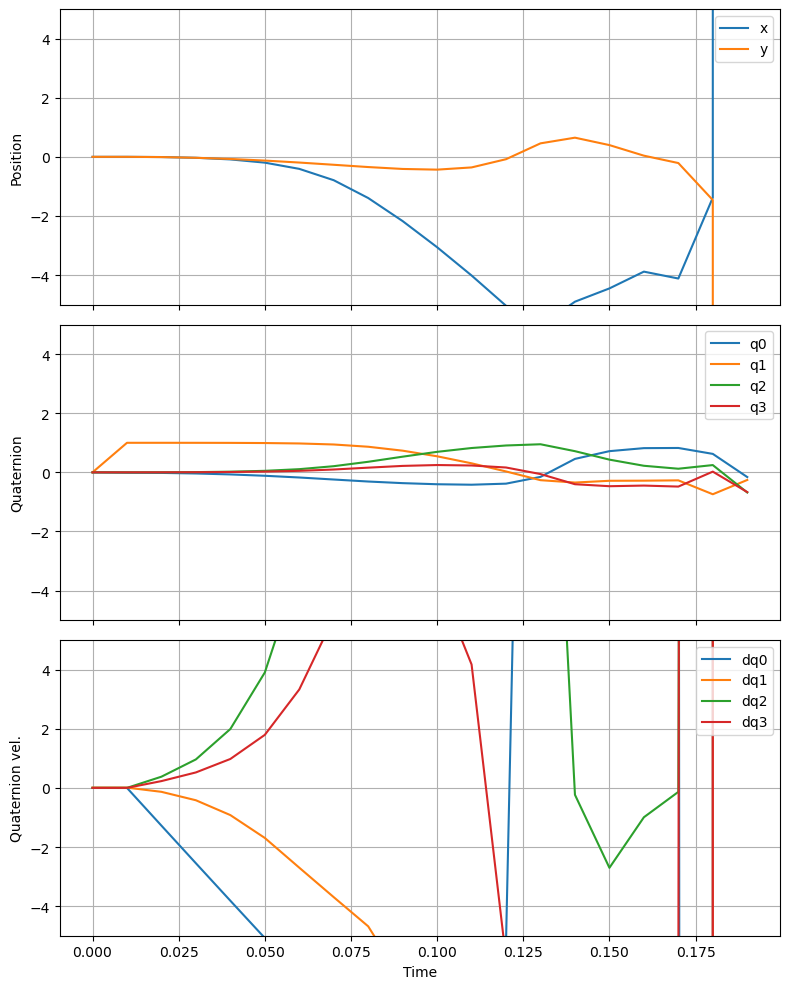

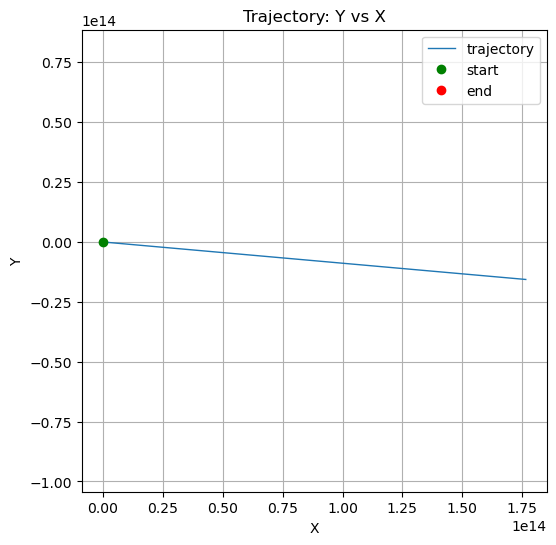

In [66]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# XY plot
for i in range(len(axs)):
    axs[i].set_ylim(-5,5)
axs[0].plot(time, motion[:,0], label='x')
axs[0].plot(time, motion[:,1], label='y')
axs[0].set_ylabel('Position')
axs[0].legend()
axs[0].grid(True)

# Quaternion q_i
axs[1].plot(time, motion[:,2], label='q0')
axs[1].plot(time, motion[:,4], label='q1')
axs[1].plot(time, motion[:,6], label='q2')
axs[1].plot(time, motion[:,8], label='q3')
axs[1].set_ylabel('Quaternion')
axs[1].legend()
axs[1].grid(True)

# Quaternion velocities dq_i
axs[2].plot(time, motion[:,3], label='dq0')
axs[2].plot(time, motion[:,5], label='dq1')
axs[2].plot(time, motion[:,7], label='dq2')
axs[2].plot(time, motion[:,9], label='dq3')
axs[2].set_ylabel('Quaternion vel.')
axs[2].set_xlabel('Time')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.plot(motion[:,0], motion[:,1], '-', lw=1, label='trajectory')
plt.plot(motion[0,0], motion[0,1], 'go', label='start')
plt.plot(motion[-1,0], motion[-1,1], 'ro', label='end')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Trajectory: Y vs X')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()
